In [1]:
import pandas as pd
from load import load_dataset

dataset = load_dataset("futbol_uruguayo.csv")

print(dataset.head())


                   home                              away       date  gh  ga  \
0           Bella Vista                 Defensor Sporting 1932-03-05   1   2   
1            CA Penarol                       River Plate 1932-03-05   1   1   
2       Central Espanol        Rampla Juniors Futbol Club 1932-03-05   1   0   
3  Montevideo Wanderers                       Racing Club 1932-03-05   3   0   
4              Nacional  Institucion Atletica Sud America 1932-03-05   2   0   

  result  record_difference  last_matches_difference  goal_difference_value  \
0      V                0.0                      0.0                    0.0   
1      E                0.0                      0.0                    0.0   
2      L                0.0                      0.0                    0.0   
3      L                0.0                      0.0                    0.0   
4      L                0.0                      0.0                    0.0   

   attack_difference  defense_difference  dr

In [2]:
#separamos cronologicamente el conjunto de entrenamiento y el de evaluacion
#la evaluacion se mantiene separada hasta haber elegido los hiperparametros

train = dataset[
    dataset["date"] < pd.Timestamp("2024-01-01")
].copy()

test = dataset[
    (dataset["date"] >= pd.Timestamp("2024-01-01"))
    & (dataset["date"] < pd.Timestamp("2026-01-01"))
].copy()

print("Cantidad de partidos de entrenamiento:", len(train))
print("Cantidad de partidos de evaluacion:", len(test))

Cantidad de partidos de entrenamiento: 14734
Cantidad de partidos de evaluacion: 472


In [4]:
import sys
import os

from pipeline import create_model_pipeline, pipeline_input_attributes


# Agrega la carpeta padre (Tarea1) al path de búsqueda de Python
sys.path.append(os.path.abspath(".."))


#hacemos el arbol de decision usando solamente el conjunto de entrenamiento
from naiveBayes.bayes import M_Estimator as BayesClassifier

bayes= BayesClassifier(m=1.0)

model = create_model_pipeline(bayes)

In [5]:
X_train = train[pipeline_input_attributes].copy()
y_train = train["result"].copy()

X_test = test[pipeline_input_attributes].copy()
y_test = test["result"].copy()

print("Filas de entrenamiento:", len(X_train))
print("Filas reservadas para evaluacion final:", len(X_test))

Filas de entrenamiento: 14734
Filas reservadas para evaluacion final: 472


In [6]:
import numpy as np

#cada temporada se valida usando solamente las temporadas anteriores
validation_years = [2020, 2021, 2022, 2023]
train_years = train["date"].dt.year.to_numpy()
temporal_splits = []

for validation_year in validation_years:
    fit_indices = np.flatnonzero(
        train_years < validation_year
    )
    validation_indices = np.flatnonzero(
        train_years == validation_year
    )

    temporal_splits.append((
        fit_indices,
        validation_indices
    ))

    print(
        f"Validacion {validation_year}:",
        f"entrenamiento={len(fit_indices)},",
        f"validacion={len(validation_indices)}"
    )

Validacion 2020: entrenamiento=13594, validacion=175
Validacion 2021: entrenamiento=13769, validacion=367
Validacion 2022: entrenamiento=14136, validacion=298
Validacion 2023: entrenamiento=14434, validacion=300


In [7]:
from sklearn.model_selection import GridSearchCV

#en esta primera busqueda variamos solamente el margen de record
param_grid = {
    #diferencia de tasa de victorias
    "preprocessing__differences__discretizer__record_margin": [
        0.025,
    ],

    #diferencia de forma reciente
    "preprocessing__differences__discretizer__last_matches_margin": [
        0.18,
    ],

    #diferencia de goles general
    "preprocessing__differences__discretizer__goal_difference_margin": [
        0.50,
    ],

    #diferencia de goles convertidos
    "preprocessing__differences__discretizer__attack_margin": [
        0.28,
    ],

    #diferencia de goles recibidos
    "preprocessing__differences__discretizer__defense_margin": [
        0.00,
    ],

    #valor de m para el m-estimador
    "model__m": [
        0.00,
    ],

    "preprocessing__draw_rate__discretizer__low_threshold": [
        0.22,
    ],
    "preprocessing__draw_rate__discretizer__high_threshold": [
        0.42,
    ],
}

scoring= {
    "accuracy": "accuracy",
    "f1_macro": "f1_macro",
}

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring=scoring,
    cv=temporal_splits,
    n_jobs=-1,
    refit="accuracy",
    verbose=1,
)

grid_search.fit(X_train, y_train)

print("Mejores hiperparametros:")
print(grid_search.best_params_)
print(f"Mejor accuracy temporal: {grid_search.best_score_:.3%}")


Fitting 4 folds for each of 1 candidates, totalling 4 fits
Mejores hiperparametros:
{'model__m': 0.0, 'preprocessing__differences__discretizer__attack_margin': 0.28, 'preprocessing__differences__discretizer__defense_margin': 0.0, 'preprocessing__differences__discretizer__goal_difference_margin': 0.5, 'preprocessing__differences__discretizer__last_matches_margin': 0.18, 'preprocessing__differences__discretizer__record_margin': 0.025, 'preprocessing__draw_rate__discretizer__high_threshold': 0.42, 'preprocessing__draw_rate__discretizer__low_threshold': 0.22}
Mejor accuracy temporal: 43.945%


In [8]:
results = pd.DataFrame(grid_search.cv_results_)

#buscamos automaticamente todas las columnas de hiperparametros
parameter_columns = [
    column
    for column in results.columns
    if column.startswith("param_")
]

score_columns = [
    "split0_test_accuracy",
    "split1_test_accuracy",
    "split2_test_accuracy",
    "split3_test_accuracy",
    "mean_test_accuracy",
    "std_test_accuracy",
    "rank_test_accuracy",
]

results = results[
    parameter_columns + score_columns
].sort_values("rank_test_accuracy")

results = results.rename(columns={
    "split0_test_accuracy": "accuracy_2020",
    "split1_test_accuracy": "accuracy_2021",
    "split2_test_accuracy": "accuracy_2022",
    "split3_test_accuracy": "accuracy_2023",
})

results.head(10)

,param_model__m,param_preprocessing__differences__discretizer__attack_margin,param_preprocessing__differences__discretizer__defense_margin,param_preprocessing__differences__discretizer__goal_difference_margin,param_preprocessing__differences__discretizer__last_matches_margin,param_preprocessing__differences__discretizer__record_margin,param_preprocessing__draw_rate__discretizer__high_threshold,param_preprocessing__draw_rate__discretizer__low_threshold,accuracy_2020,accuracy_2021,accuracy_2022,accuracy_2023,mean_test_accuracy,std_test_accuracy,rank_test_accuracy
0,0.0,0.28,0.0,0.5,0.18,0.025,0.42,0.22,0.4,0.47139,0.459732,0.426667,0.439447,0.028068,1


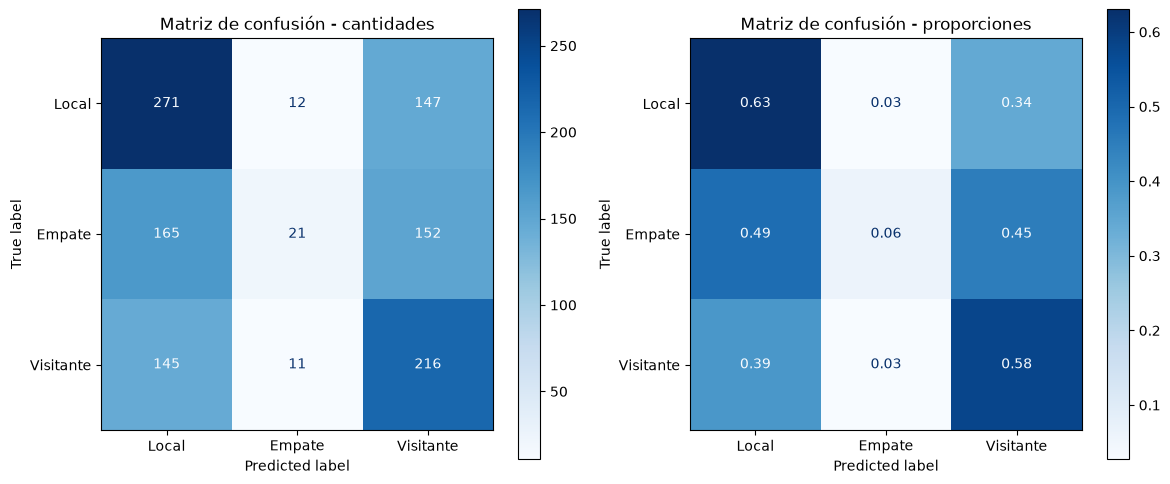

              precision    recall  f1-score   support

       Local       0.47      0.63      0.54       430
      Empate       0.48      0.06      0.11       338
   Visitante       0.42      0.58      0.49       372

    accuracy                           0.45      1140
   macro avg       0.45      0.42      0.38      1140
weighted avg       0.45      0.45      0.39      1140



In [9]:
from sklearn.base import clone
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
)
import matplotlib.pyplot as plt
import numpy as np


real_results = []
predicted_results = []

#volvemos a entrenar el mejor modelo para cada division temporal
for fit_indices, validation_indices in temporal_splits:

    fold_model = clone(
        grid_search.best_estimator_
    )

    fold_model.fit(
        X_train.iloc[fit_indices],
        y_train.iloc[fit_indices],
    )

    fold_predictions = fold_model.predict(
        X_train.iloc[validation_indices]
    )

    real_results.extend(
        y_train.iloc[validation_indices]
    )

    predicted_results.extend(
        fold_predictions
    )


real_results = np.asarray(real_results)
predicted_results = np.asarray(predicted_results)

labels = ["L", "E", "V"]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

#cantidad de partidos
ConfusionMatrixDisplay.from_predictions(
    real_results,
    predicted_results,
    labels=labels,
    display_labels=[
        "Local",
        "Empate",
        "Visitante",
    ],
    cmap="Blues",
    values_format="d",
    ax=axes[0],
)

axes[0].set_title(
    "Matriz de confusión - cantidades"
)

#porcentaje correcto dentro de cada clase real
ConfusionMatrixDisplay.from_predictions(
    real_results,
    predicted_results,
    labels=labels,
    display_labels=[
        "Local",
        "Empate",
        "Visitante",
    ],
    normalize="true",
    cmap="Blues",
    values_format=".2f",
    ax=axes[1],
)

axes[1].set_title(
    "Matriz de confusión - proporciones"
)

plt.tight_layout()
plt.show()


print(
    classification_report(
        real_results,
        predicted_results,
        labels=labels,
        target_names=[
            "Local",
            "Empate",
            "Visitante",
        ],
        zero_division=0,
    )
)

In [10]:
from sklearn.naive_bayes import CategoricalNB
from sklearn.metrics import accuracy_score, classification_report

# Extraemos el preprocesamiento con los mejores hiperparametros encontrados
best_preprocessing = grid_search.best_estimator_.named_steps['preprocessing']

# Transformamos los datos
X_train_transformed = best_preprocessing.transform(X_train)
X_test_transformed = best_preprocessing.transform(X_test)

# Entrenamos el CategoricalNB de scikit-learn
# alpha cumple un rol similar a tu hiperparametro m (suavizado de Laplace)
# Usamos alpha=1e-10 porque tu mejor m fue 0.0
sklearn_nb = CategoricalNB(alpha=1e-10)
sklearn_nb.fit(X_train_transformed, y_train)
sklearn_predictions = sklearn_nb.predict(X_test_transformed)

print("Resultados de Scikit-Learn (CategoricalNB):")
print(f"Accuracy: {accuracy_score(y_test, sklearn_predictions):.3%}")
print(classification_report(y_test, sklearn_predictions, zero_division=0))

print('-'*40 + '\n')

# Evaluamos tu modelo M_Estimator en el mismo conjunto de test
custom_predictions = grid_search.best_estimator_.predict(X_test)

print("\nResultados de tu Modelo Personalizado (M_Estimator):")
print(f"Accuracy: {accuracy_score(y_test, custom_predictions):.3%}")
print(classification_report(y_test, custom_predictions, zero_division=0))


Resultados de Scikit-Learn (CategoricalNB):
Accuracy: 49.788%
              precision    recall  f1-score   support

           E       0.59      0.08      0.14       131
           L       0.51      0.75      0.61       190
           V       0.47      0.55      0.50       151

    accuracy                           0.50       472
   macro avg       0.52      0.46      0.42       472
weighted avg       0.52      0.50      0.44       472

----------------------------------------


Resultados de tu Modelo Personalizado (M_Estimator):
Accuracy: 49.788%
              precision    recall  f1-score   support

           E       0.59      0.08      0.14       131
           L       0.51      0.75      0.61       190
           V       0.47      0.55      0.50       151

    accuracy                           0.50       472
   macro avg       0.52      0.46      0.42       472
weighted avg       0.52      0.50      0.44       472

